### 1. Import the libraries

#### 1.1. Import the needed libraries

In [ ]:
from utils.data_loader import DatasetLoader
from utils.data_visualization import DataVisualization
from utils.preprocessing import Preprocessor
from utils.feature_selection import MutualInformation
from utils.models import ensemble_models
from utils.model_evaluator import ModelEvaluator
from utils.tree_shap import SHAPTreeExplainer

import warnings
warnings.filterwarnings('ignore')


#### 1.2. Define the global variables 

In [2]:
binary_target = 'label' 
multiclass_target = 'type' 
all_target_columns = [binary_target, multiclass_target]
columns_to_drop = ["src_ip", "src_port", "dst_ip", "dst_port"] 
categorical_missing_token = '-'
numeric_imputation_strategy = 'median'
categorical_imputation_strategy = 'most_frequent'
shuffle=True
random_state=80


### 2. Load the dataset

In [3]:
ton_iot_loader = DatasetLoader(dataset_name="TON_IoT")

df = ton_iot_loader.load()
df


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211038,192.168.1.32,48286,176.28.50.165,80,tcp,http,65.376610,2665,322,S3,...,0,0,-,-,-,-,-,-,1,xss
211039,192.168.1.32,48288,176.28.50.165,80,tcp,http,65.710346,1987,322,S3,...,0,0,-,-,-,-,-,-,1,xss
211040,192.168.1.32,48292,176.28.50.165,80,tcp,http,65.766512,3922,322,S3,...,0,0,-,-,-,-,-,-,1,xss
211041,192.168.1.32,48294,176.28.50.165,80,tcp,http,65.753940,2401,322,S3,...,0,0,-,-,-,-,-,-,1,xss


### 3. Data Exploration

#### 3.1. Basic Data Analysis

In [4]:
ton_iot_loader.info()

,Datatype,Not nulls,Nulls,% Nulls,Unique cnt,Mean,StDev,Min,Q25,Q50,Q75,Max
src_ip,object,211043,0,0.0,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_port,int64,211043,0,0.0,26628,38646.519543,1.930727e+04,1.0,34608.0,44754.00000,51133.000000,6.552800e+04
dst_ip,object,211043,0,0.0,753,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dst_port,int64,211043,0,0.0,2039,3495.153770,1.019162e+04,0.0,65.0,80.00000,1253.000000,6.546700e+04
proto,object,211043,0,0.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,object,211043,0,0.0,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,float64,211043,0,0.0,68570,7.700887,5.641419e+02,0.0,0.0,0.00017,0.054196,9.351693e+04
src_bytes,int64,211043,0,0.0,2199,258113.564274,1.709490e+07,0.0,0.0,0.00000,130.000000,3.890855e+09
dst_bytes,int64,211043,0,0.0,2338,258804.571575,1.802563e+07,0.0,0.0,0.00000,89.000000,3.913853e+09
conn_state,object,211043,0,0.0,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 3.2. Target Features

In [5]:
viz = DataVisualization(
    df,
    label_columns=all_target_columns
)

##### 3.2.1. Binary class

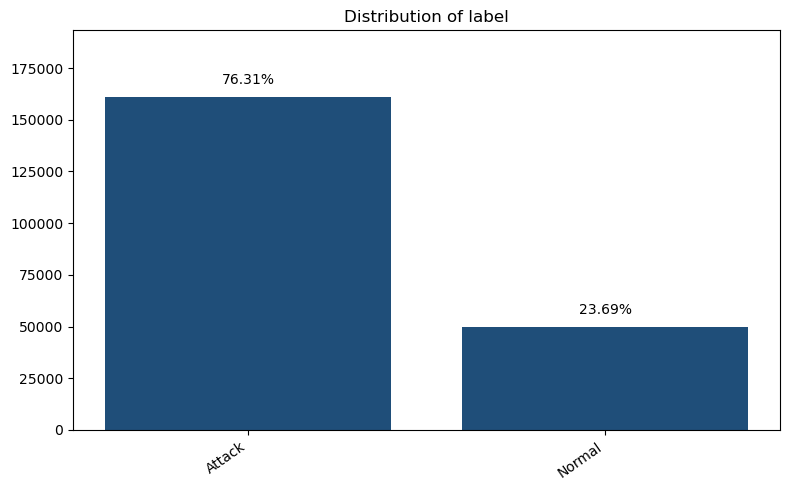

In [6]:
viz.target_distribution(
    label_column=binary_target,
    label_mapping={1: "Attack", 0: "Normal"}
)


##### 3.2.2. Multiclass

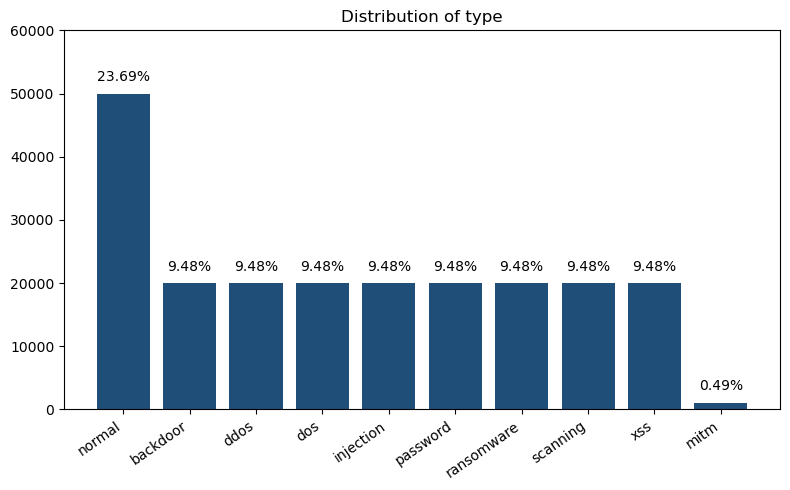

In [7]:
viz.target_distribution(label_column=multiclass_target)


#### 3.3. Numerical Data

Histogram

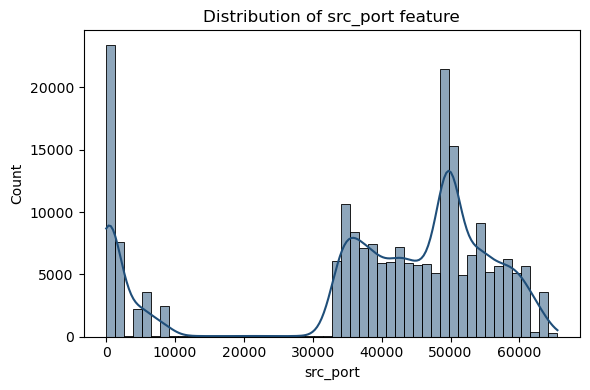

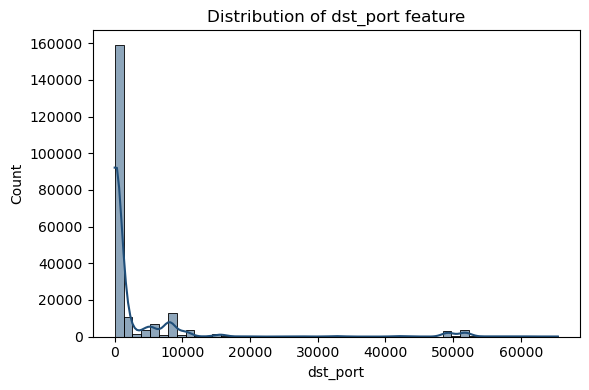

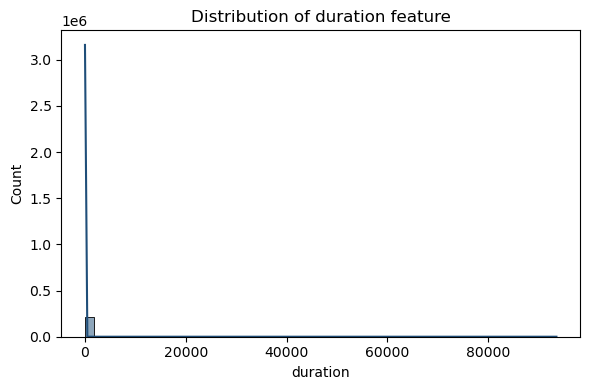

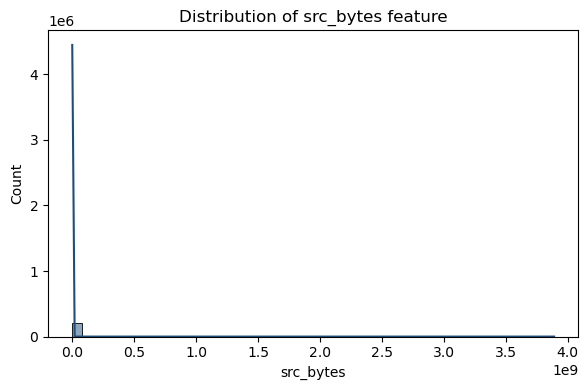

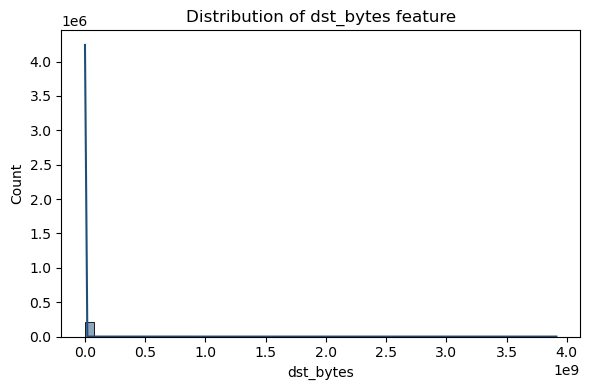

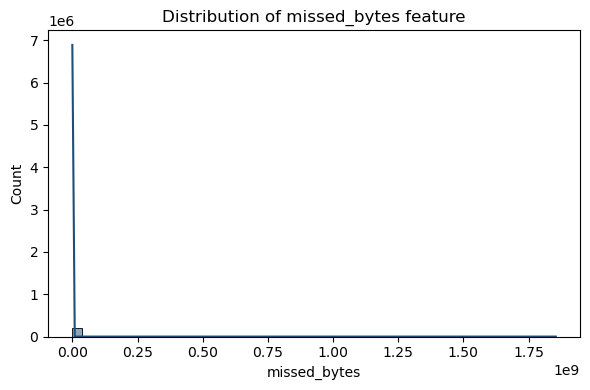

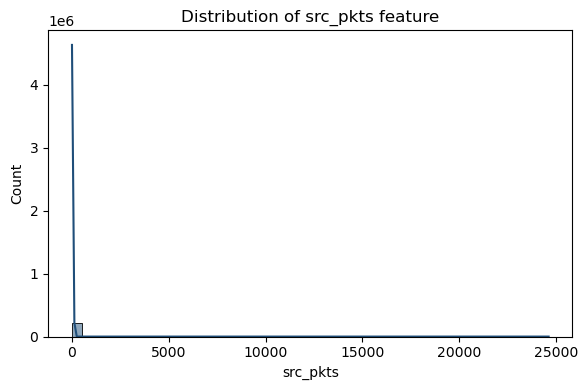

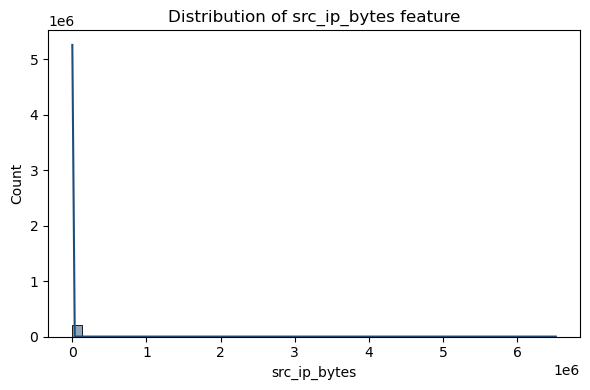

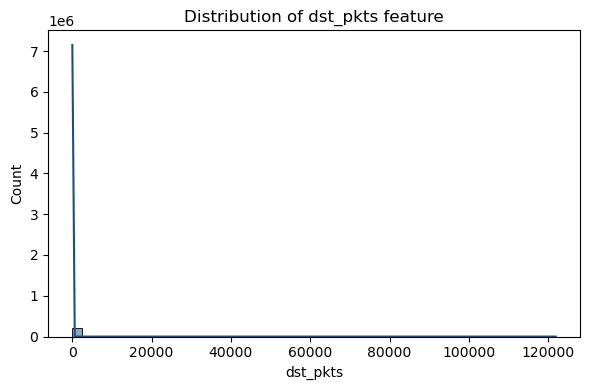

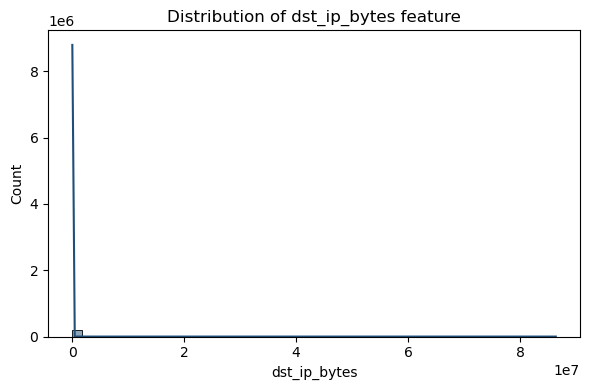

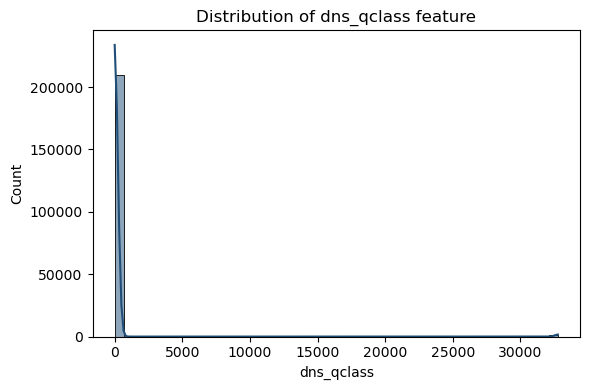

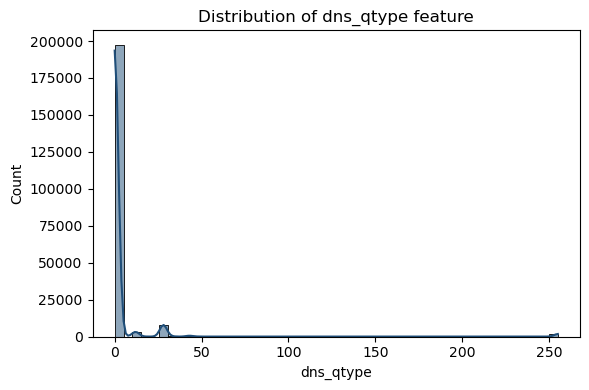

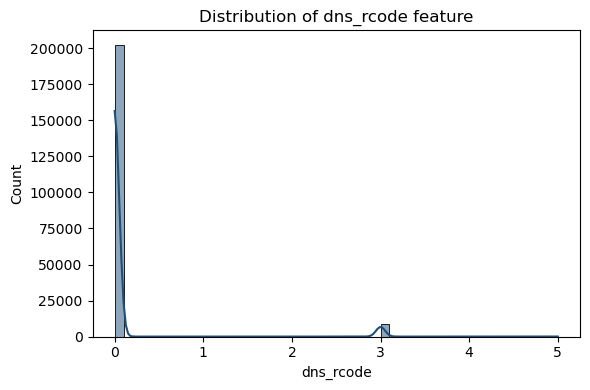

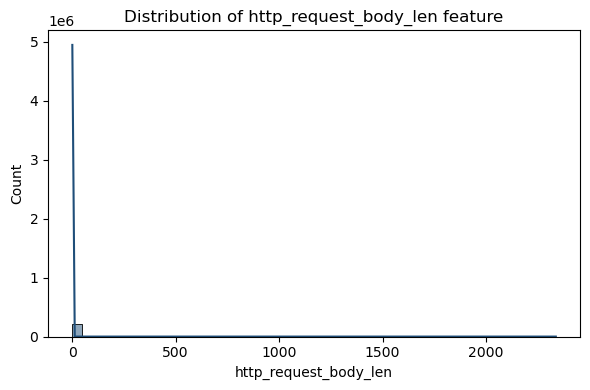

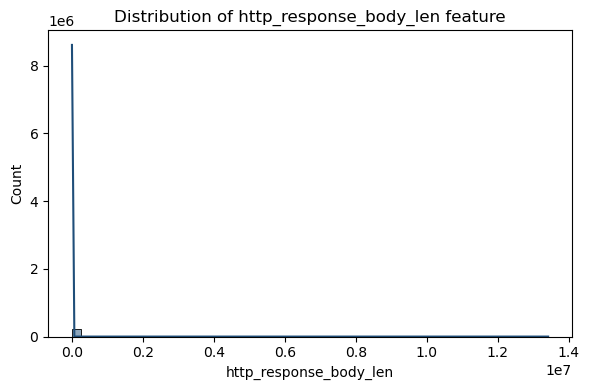

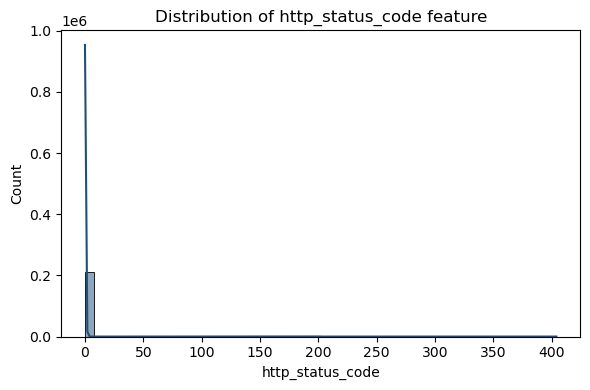

In [8]:
viz.numeric_distribution()


Boxplot

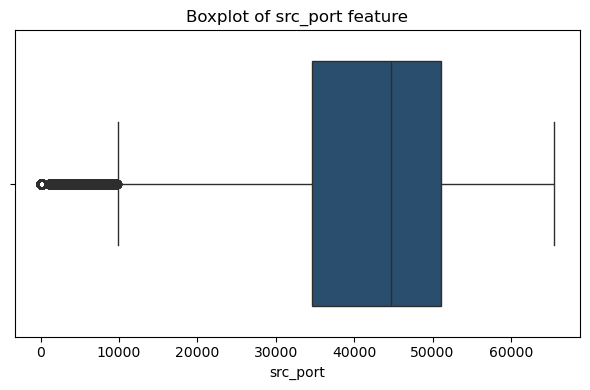

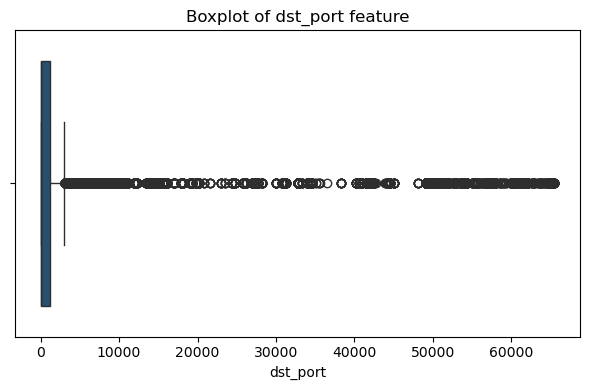

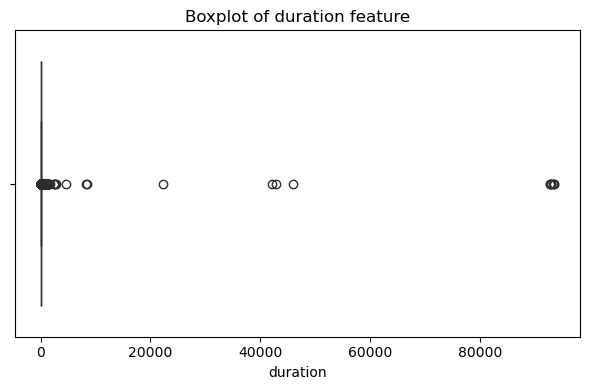

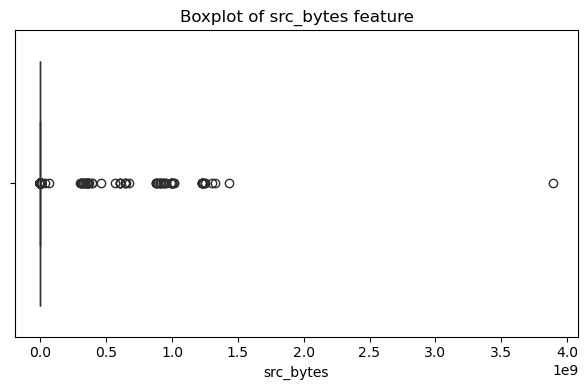

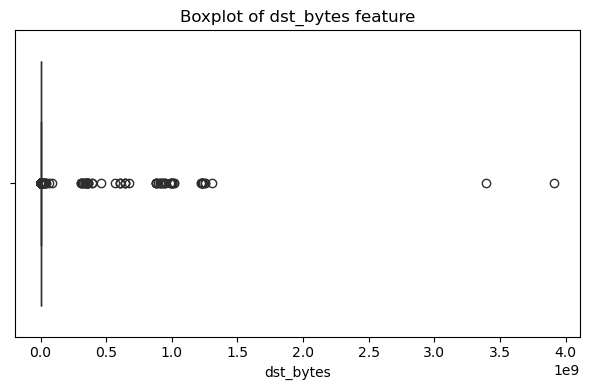

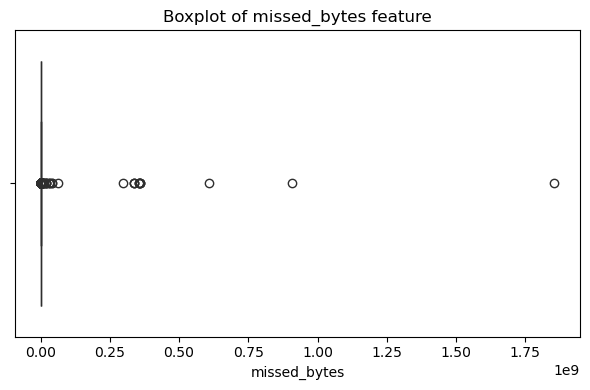

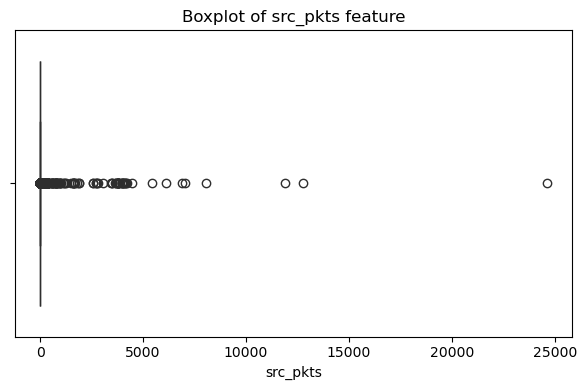

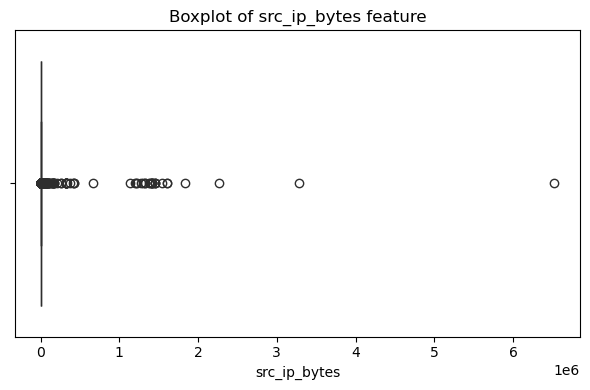

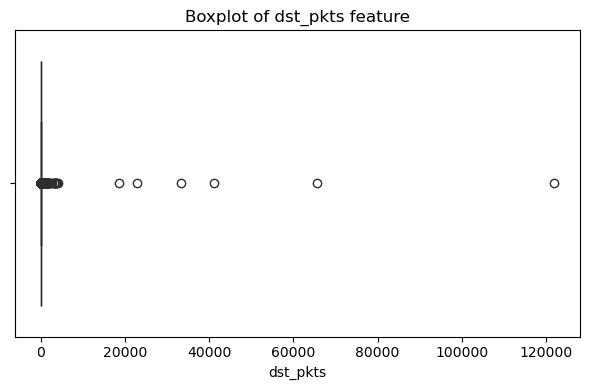

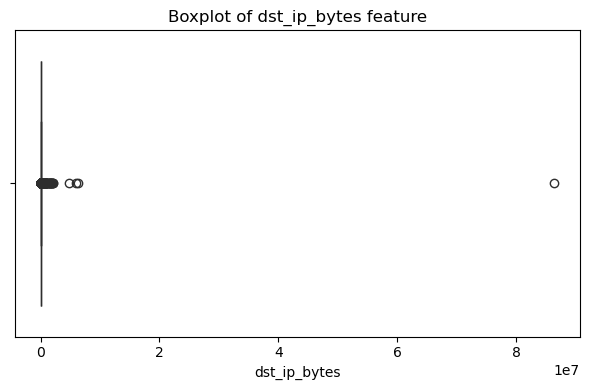

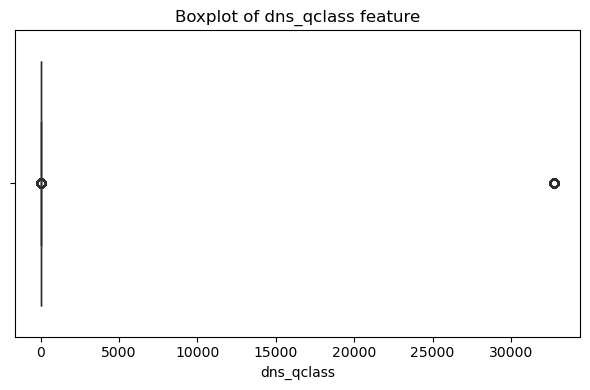

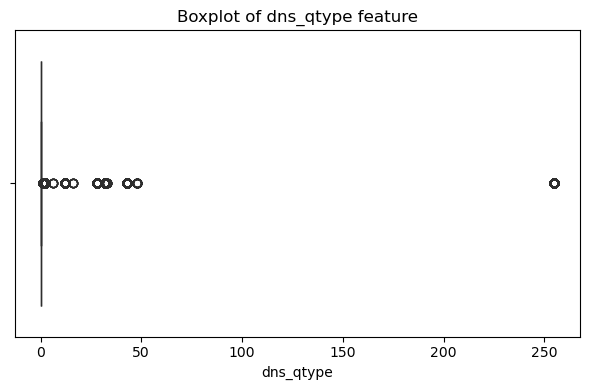

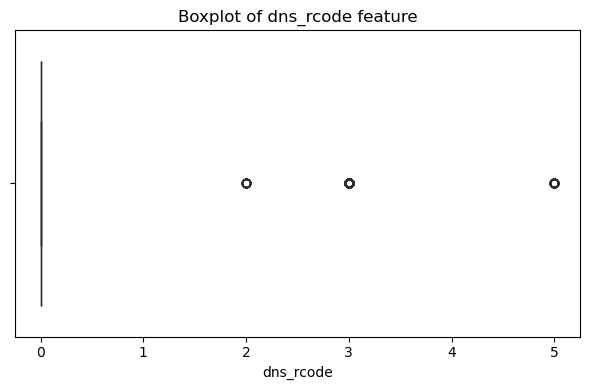

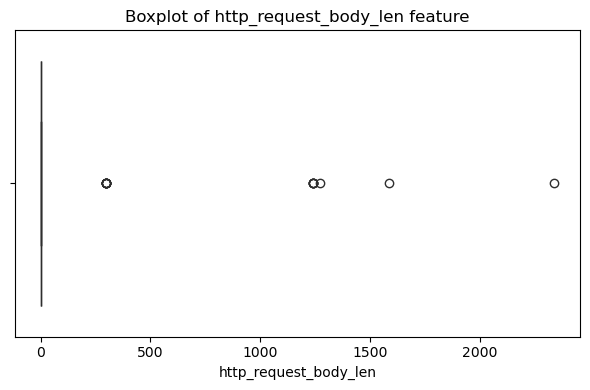

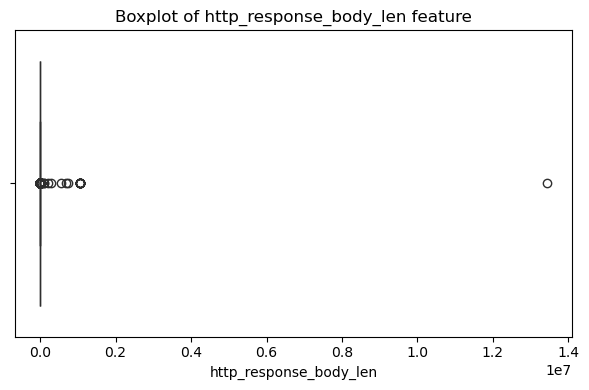

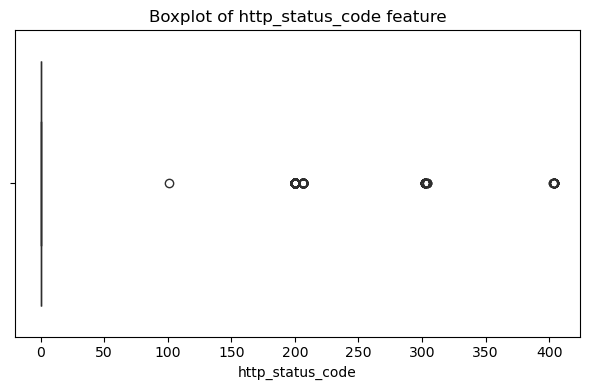

In [9]:
viz.boxplot()

#### 3.4. Categorical Data

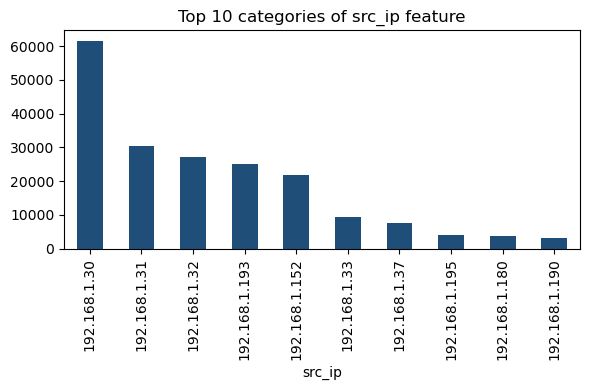

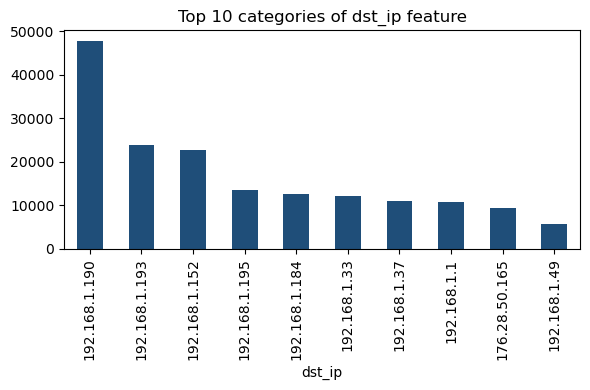

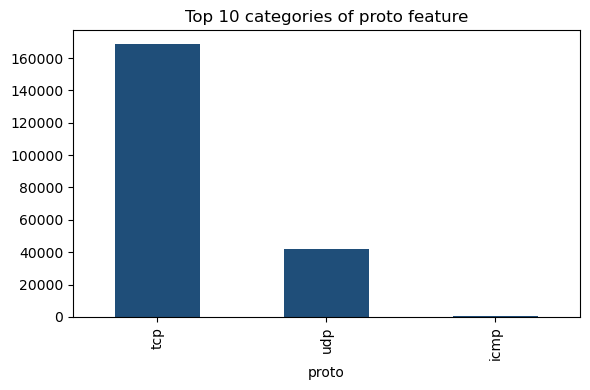

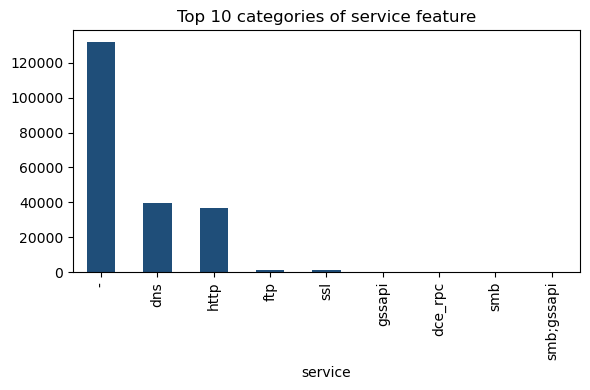

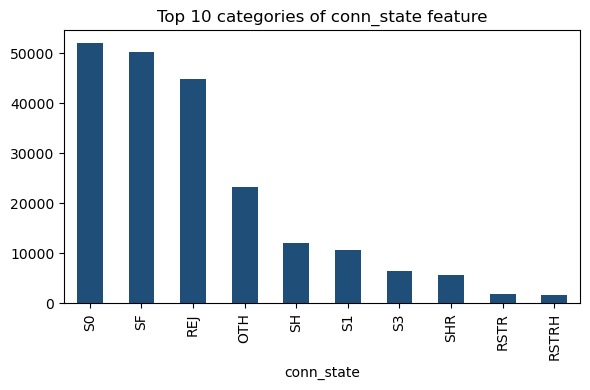

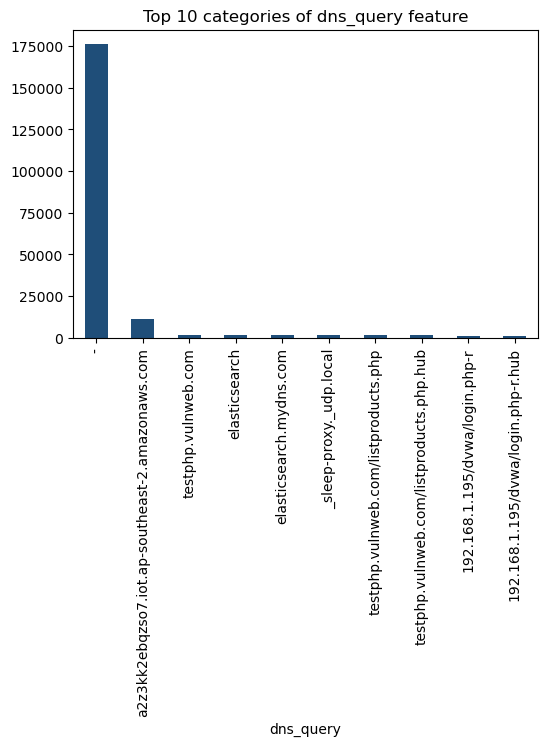

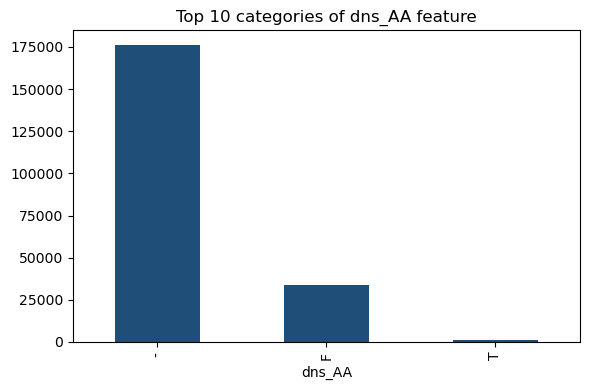

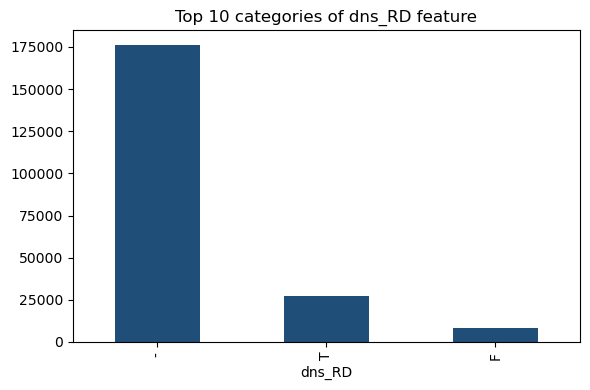

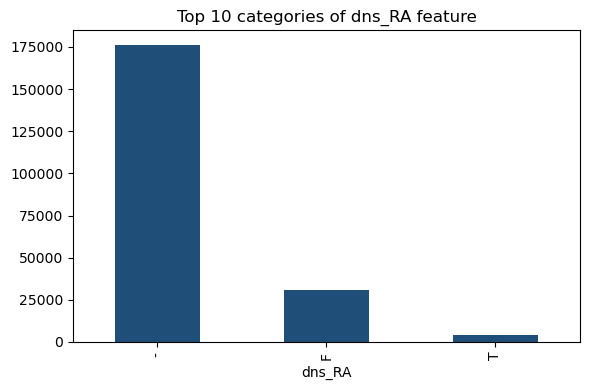

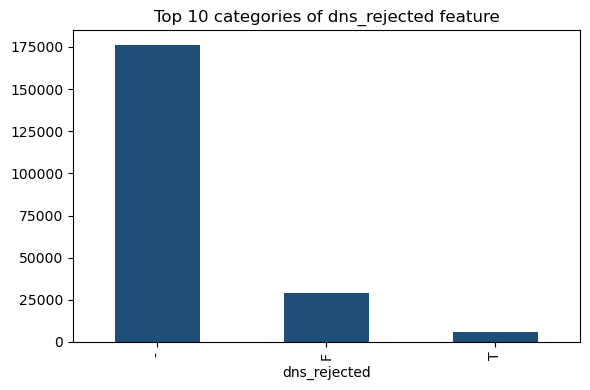

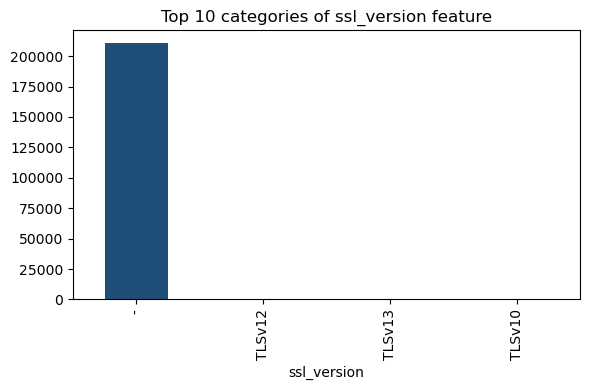

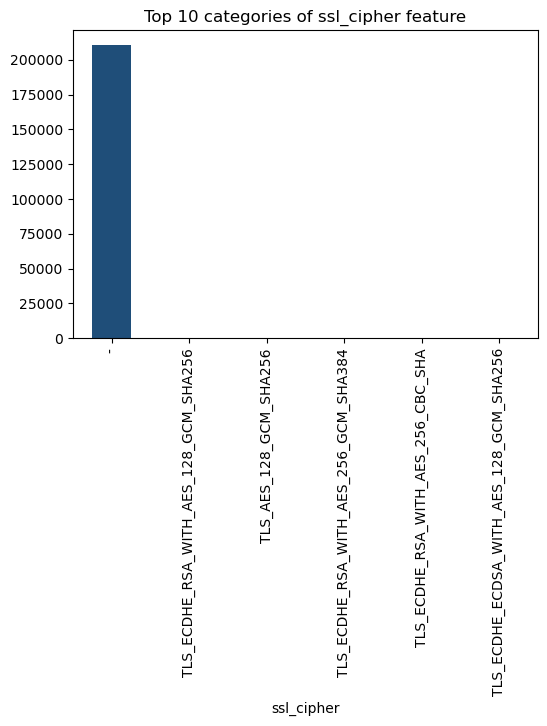

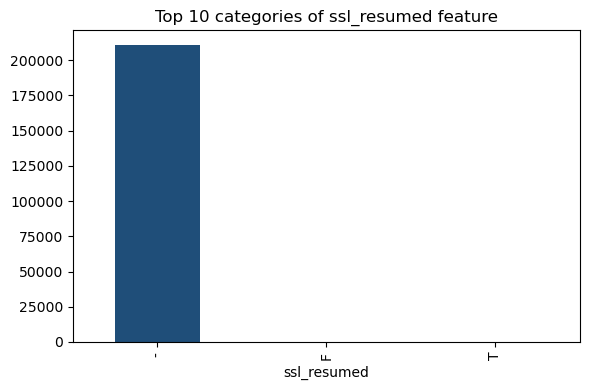

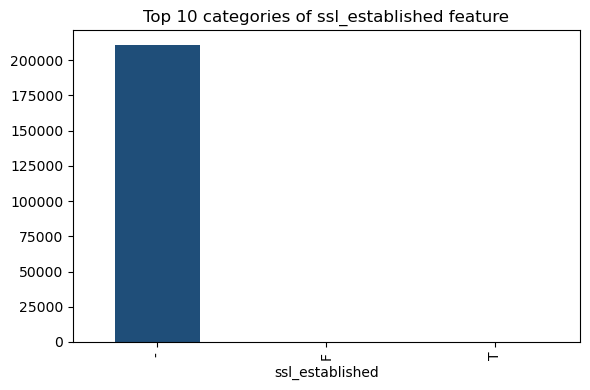

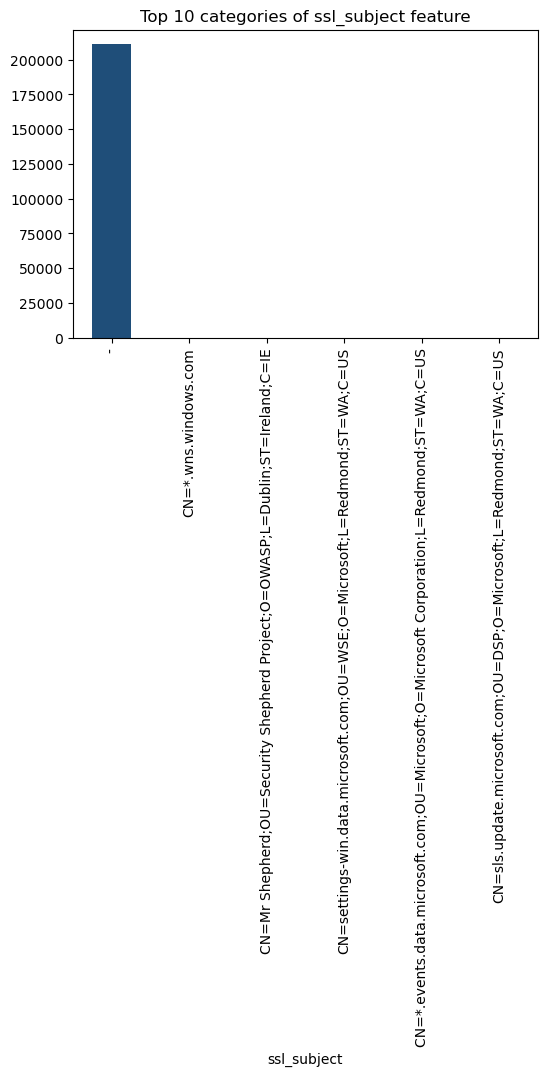

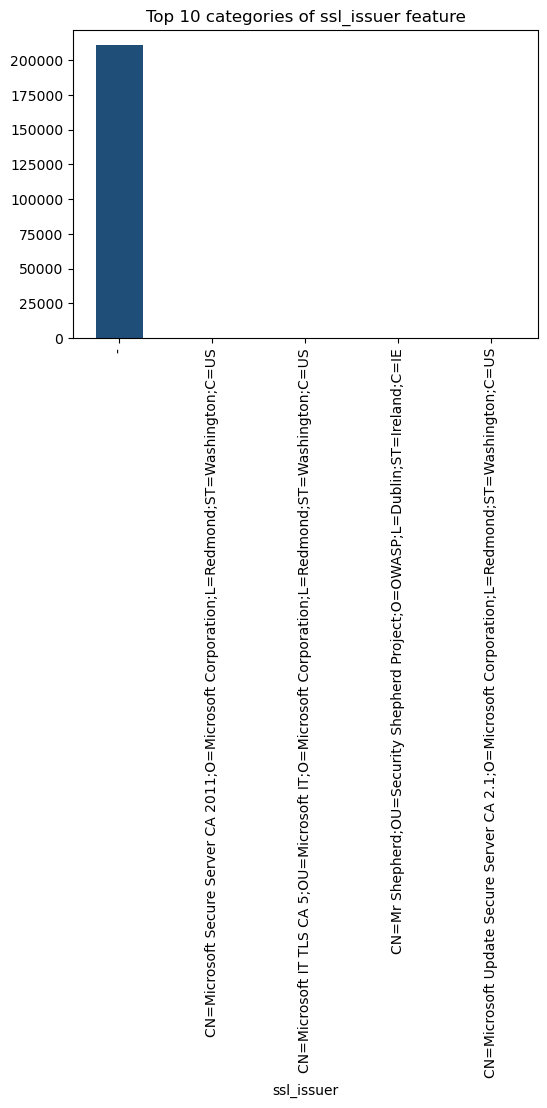

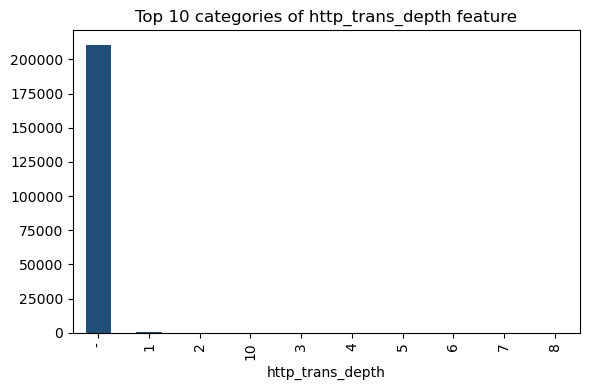

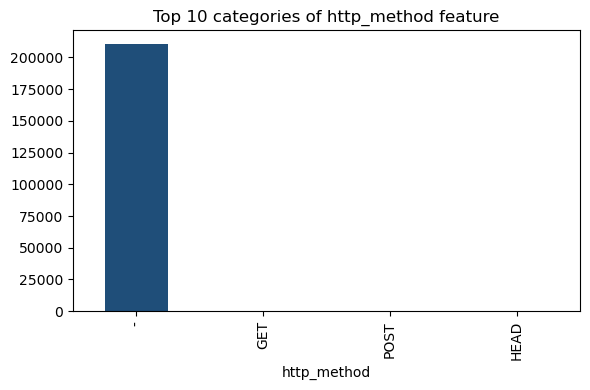

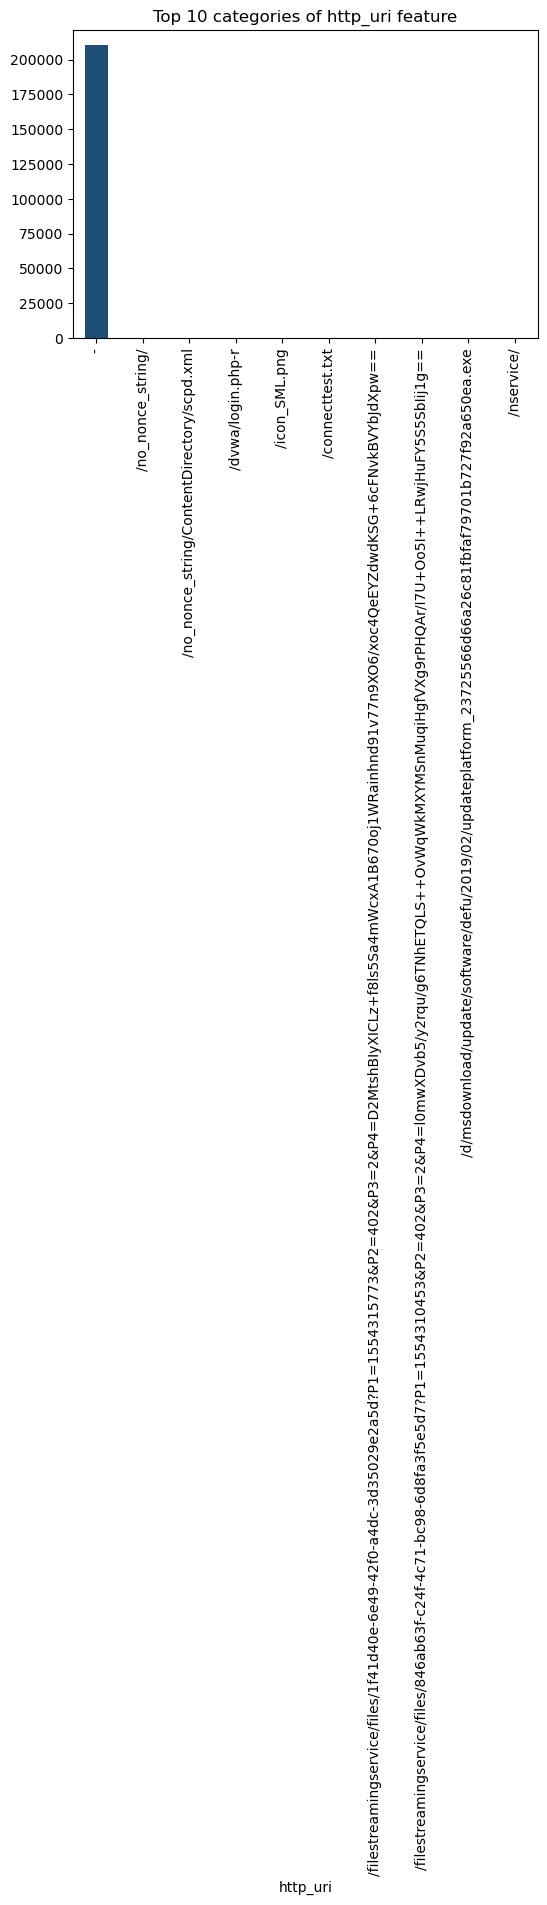

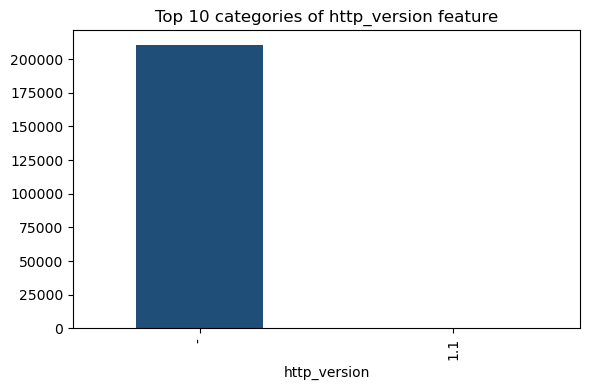

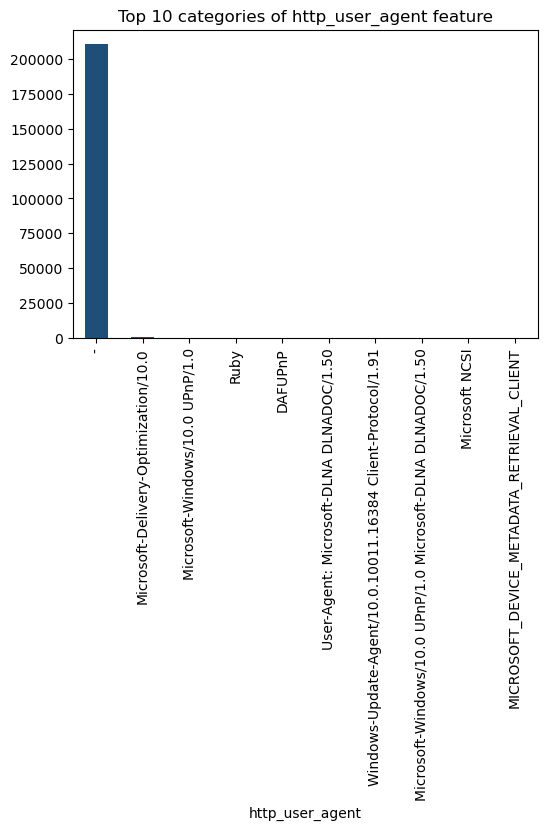

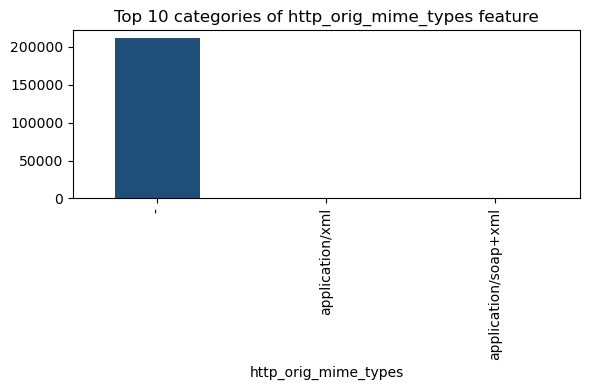

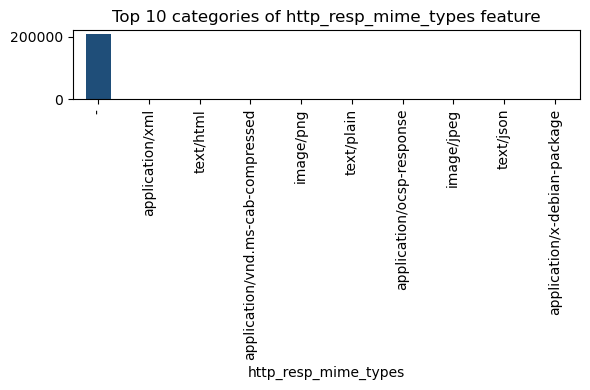

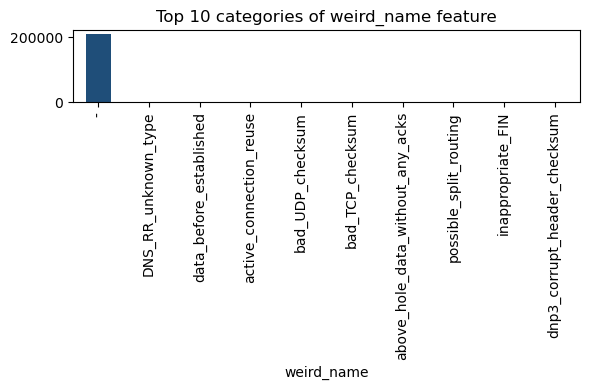

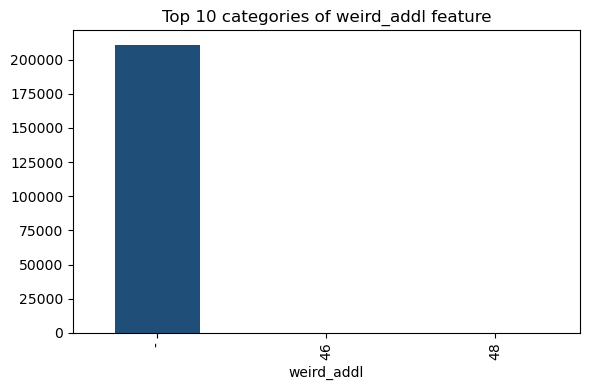

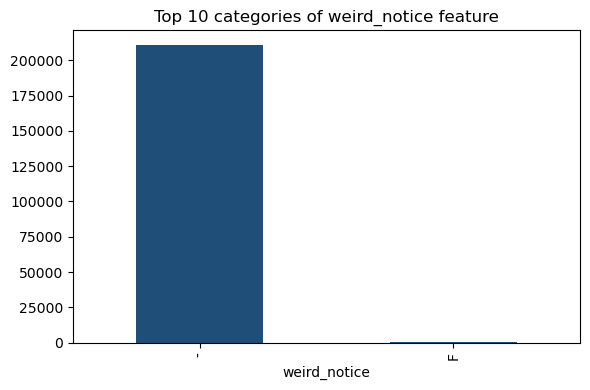

In [10]:
viz.categorical_distribution()

### 4. Preprocessing

#### 4.1. Binary class

In [4]:
preprocessor_BC = Preprocessor(
    target_column=binary_target,
    all_target_columns=all_target_columns,
    columns_to_drop=columns_to_drop,
    categorical_missing_token=categorical_missing_token,
    numeric_imputation_strategy=numeric_imputation_strategy,
    categorical_imputation_strategy=categorical_imputation_strategy
)

df_BC = preprocessor_BC.clean_dataframe(df)

X_BC = df_BC.drop(columns=[binary_target]).reset_index(drop=True)
y_BC = df_BC[binary_target].reset_index(drop=True)


Duplicated rows: 20569
Dataframe shape: (190474, 44)
['type'] target column eliminated
['src_ip', 'src_port', 'dst_ip', 'dst_port'] columns eliminated


#### 4.2. Multiclass

In [5]:
preprocessor_MC = Preprocessor(
    target_column=multiclass_target,
    all_target_columns=all_target_columns,
    columns_to_drop=columns_to_drop,
    categorical_missing_token=categorical_missing_token,
    numeric_imputation_strategy=numeric_imputation_strategy,
    categorical_imputation_strategy=categorical_imputation_strategy
)

df_MC = preprocessor_MC.clean_dataframe(df)

X_MC = df_MC.drop(columns=[multiclass_target]).reset_index(drop=True)
y_MC = df_MC[multiclass_target].reset_index(drop=True)


Duplicated rows: 20569
Dataframe shape: (190474, 44)
['label'] target column eliminated
['src_ip', 'src_port', 'dst_ip', 'dst_port'] columns eliminated


### 5. Feature Selection

#### 5.1. Binary class

In [6]:
mi_BC = MutualInformation(
    threshold=0.05,
    random_state=random_state
)


#### 5.2. Multiclass

In [7]:
mi_MC = MutualInformation(
    threshold=0.05,
    random_state=random_state
)


### 6. Train the models

#### 6.1. Binary class

In [8]:
# Models with default parameters
models_BC = ensemble_models(task_type="binary", random_state=random_state)
models_BC


{'RandomForest': RandomForestClassifier(random_state=80),
 'ExtraTrees': ExtraTreesClassifier(random_state=80),
 'CatBoost': CatBoostClassifier(allow_writing_files=False, random_state=80, verbose=False),
 'LightGBM': LGBMClassifier(random_state=80, verbosity=-1),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimat

X_train shape: (152379, 38)
y_train shape: (152379,)
X_test shape: (38095, 38)
y_test shape: (38095,)
14 numeric features: ['duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len', 'http_response_body_len', 'http_status_code']
24 categorical features: ['proto', 'service', 'conn_state', 'dns_query', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']
Total features after preprocessing: 910
Mutual Information selected 26 features: ['src_ip_bytes', 'dst_ip_bytes', 'proto_tcp', 'src_bytes', 'proto_udp', 'duration', 'service_dns', 'dns_rejected_F', 'src_pkts', 'dns_query_Missing', 'dns_RD_Missing', 'dns_RA_Missing', 'dn

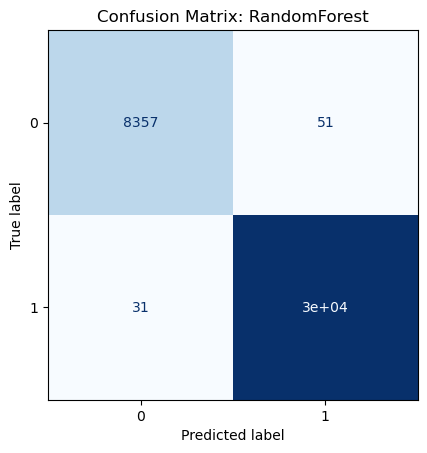


Running model: ExtraTrees


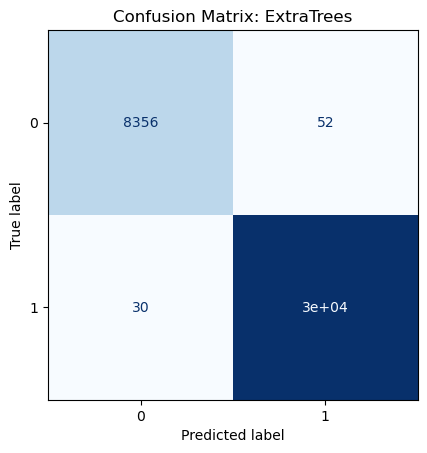


Running model: CatBoost


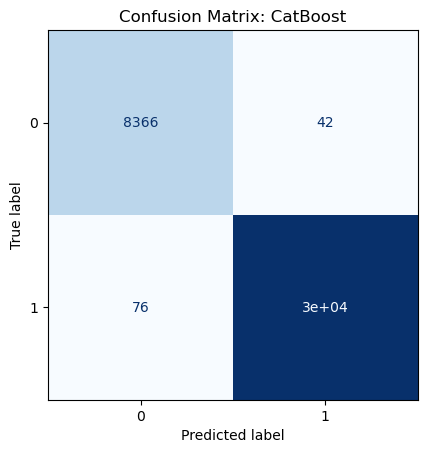


Running model: LightGBM


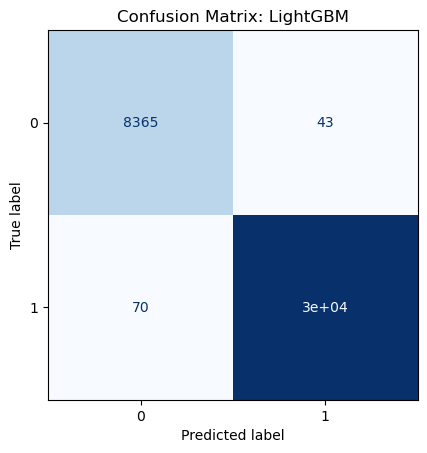


Running model: XGBoost


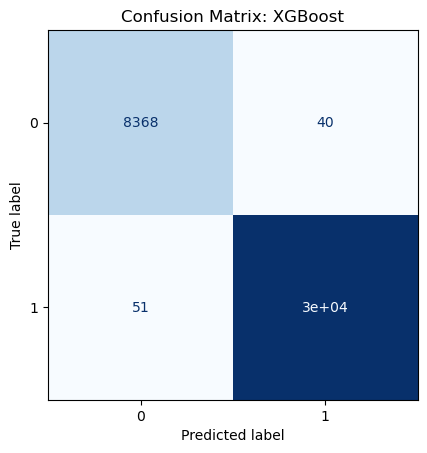

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,time
0,RandomForest,0.999398,0.997847,0.998906,0.998283,0.999891,0.998956,0.999398,0.998619,17.048774
1,ExtraTrees,0.999398,0.997847,0.998906,0.998250,0.999891,0.998989,0.999398,0.998619,10.406621
2,CatBoost,0.997436,0.996902,0.997591,0.998584,0.997280,0.997440,0.997435,0.998011,13.268238
3,LightGBM,0.997465,0.997034,0.997532,0.998550,0.997398,0.997642,0.997465,0.998096,1.657856
4,XGBoost,0.998577,0.997611,0.998283,0.998652,0.998872,0.998282,0.998577,0.998467,2.369855


In [9]:
runner_BC = ModelEvaluator(
    test_size=0.2,
    random_state=random_state,
    task_type="binary"
)

results_BC = runner_BC.run(
    models=models_BC,
    preprocessor=preprocessor_BC,
    X=X_BC,
    y=y_BC,
    feature_selector=mi_BC
)

results_BC

# 5min

#### 6.2. Multiclass

In [10]:
models_MC = ensemble_models(task_type="multiclass", random_state=random_state)
models_MC


{'RandomForest': RandomForestClassifier(random_state=80),
 'ExtraTrees': ExtraTreesClassifier(random_state=80),
 'CatBoost': CatBoostClassifier(allow_writing_files=False, random_state=80, verbose=False),
 'LightGBM': LGBMClassifier(random_state=80, verbosity=-1),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estima

{'backdoor': 0, 'ddos': 1, 'dos': 2, 'injection': 3, 'mitm': 4, 'normal': 5, 'password': 6, 'ransomware': 7, 'scanning': 8, 'xss': 9}
X_train shape: (152379, 38)
y_train shape: (152379,)
X_test shape: (38095, 38)
y_test shape: (38095,)
14 numeric features: ['duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len', 'http_response_body_len', 'http_status_code']
24 categorical features: ['proto', 'service', 'conn_state', 'dns_query', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']
Total features after preprocessing: 924
Mutual Information selected 33 features: ['src_ip_bytes', 'dst_ip_bytes', 'duration', 'src_bytes

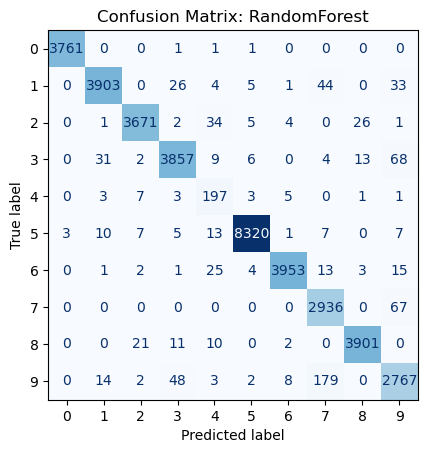


Running model: ExtraTrees


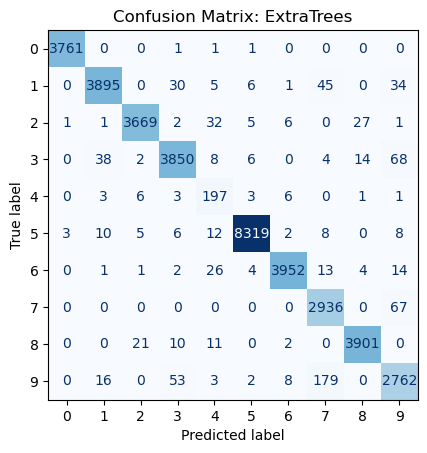


Running model: CatBoost


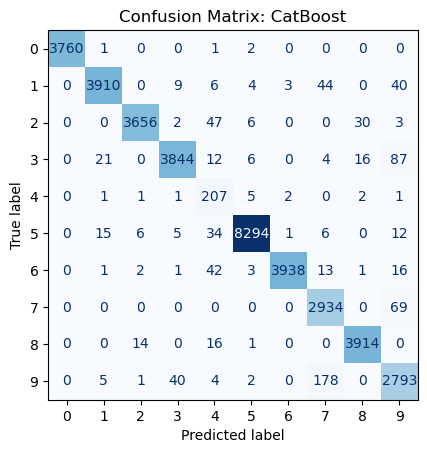


Running model: LightGBM


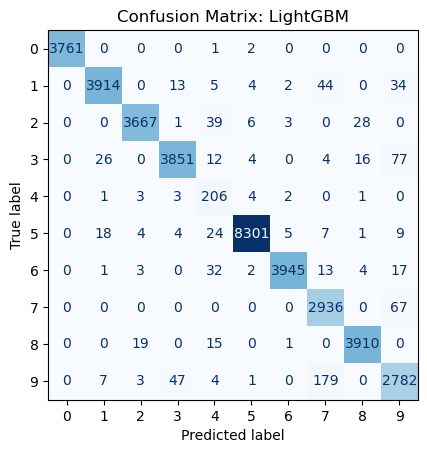


Running model: XGBoost


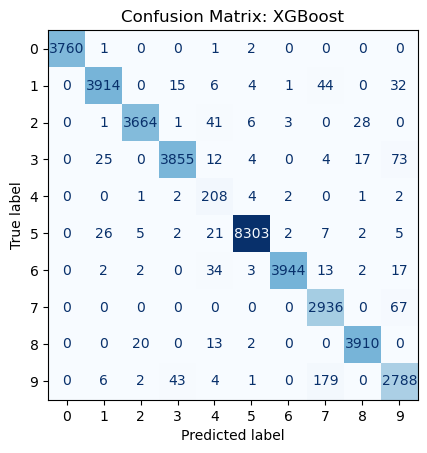

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,time
0,RandomForest,0.989678,0.978239,0.989924,0.979102,0.989678,0.978239,0.989718,0.978488,32.928086
1,ExtraTrees,0.989696,0.977609,0.989940,0.978454,0.989696,0.977609,0.989734,0.977849,25.478180
2,CatBoost,0.979443,0.977819,0.979783,0.979823,0.979443,0.977819,0.979494,0.978445,226.682084
3,LightGBM,0.982128,0.978422,0.982377,0.979869,0.982128,0.978422,0.982162,0.978856,9.343356
4,XGBoost,0.981341,0.978659,0.981604,0.980121,0.981341,0.978659,0.981376,0.979093,9.797783


In [11]:
runner_MC = ModelEvaluator(
    test_size=0.2,
    random_state=random_state,
    task_type="multiclass"
)

results_MC = runner_MC.run(
    models=models_MC,
    preprocessor=preprocessor_MC,
    X=X_MC,
    y=y_MC,
    feature_selector=mi_MC
)

results_MC

# 12min

### 7. TreeSHAP

#### 7.1. Binary Class

In [12]:
explainer_BC = SHAPTreeExplainer(task_type="binary", sample_size=2000, random_state=random_state)

RandomForest

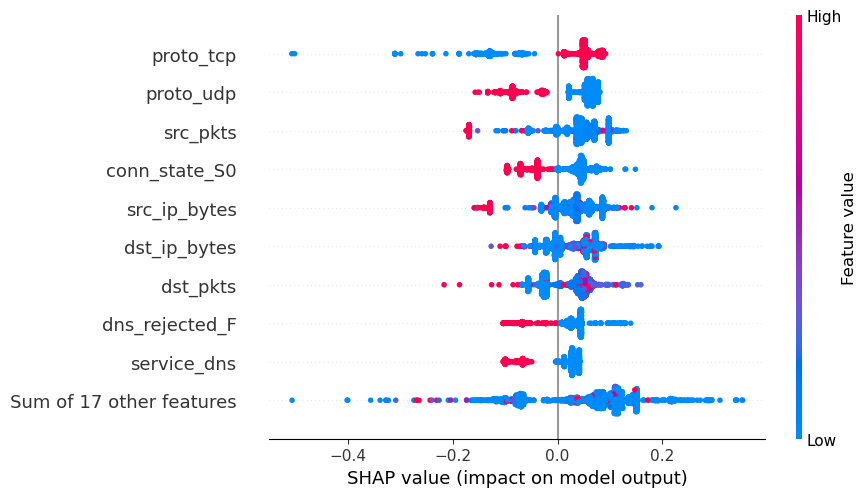

In [13]:
model_BC_rf, X_train_BC_rf, y_train_BC_rf, X_test_BC_rf, y_test_BC_rf = (
    runner_BC.get_model_data("RandomForest")
)

explainer_BC.plot_beeswarm(model_BC_rf, X_test_BC_rf)

ExtraTrees

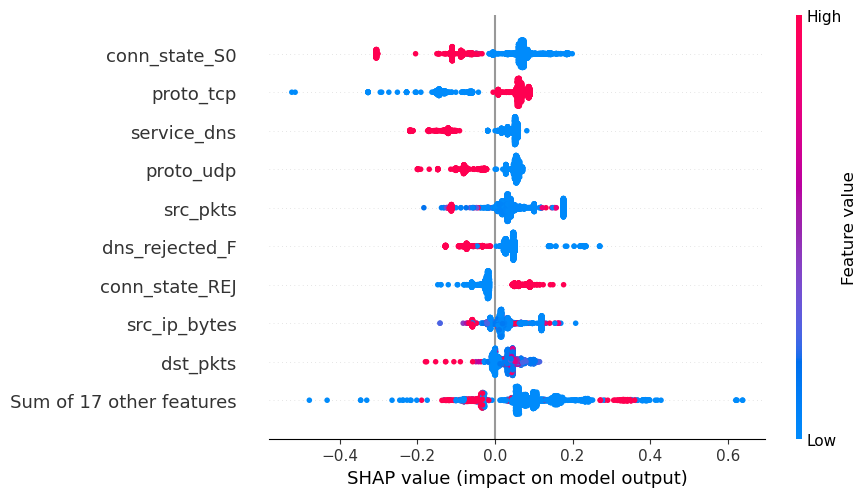

In [14]:
model_BC_et, X_train_BC_et, y_train_BC_et, X_test_BC_et, y_test_BC_et = (
    runner_BC.get_model_data("ExtraTrees")
)

explainer_BC.plot_beeswarm(model_BC_et, X_test_BC_et)

CatBoost

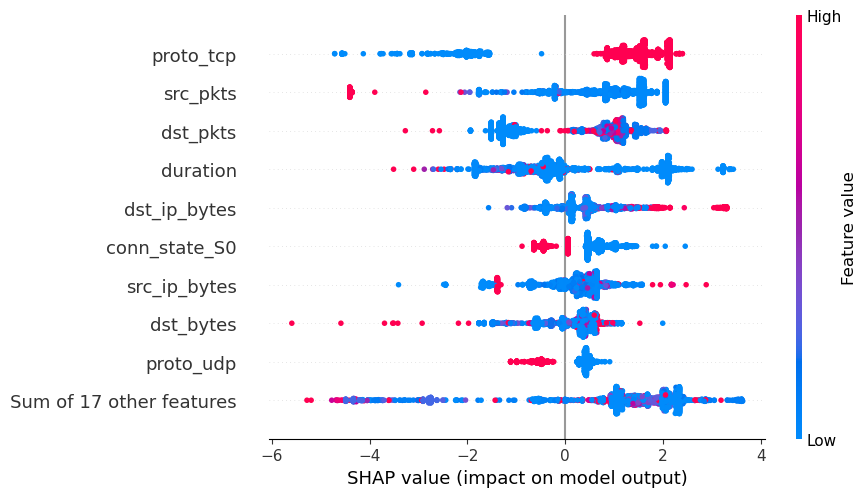

In [15]:
model_BC_cb, X_train_BC_cb, y_train_BC_cb, X_test_BC_cb, y_test_BC_cb = (
    runner_BC.get_model_data("CatBoost")
)

explainer_BC.plot_beeswarm(model_BC_cb, X_test_BC_cb)

XGBoost

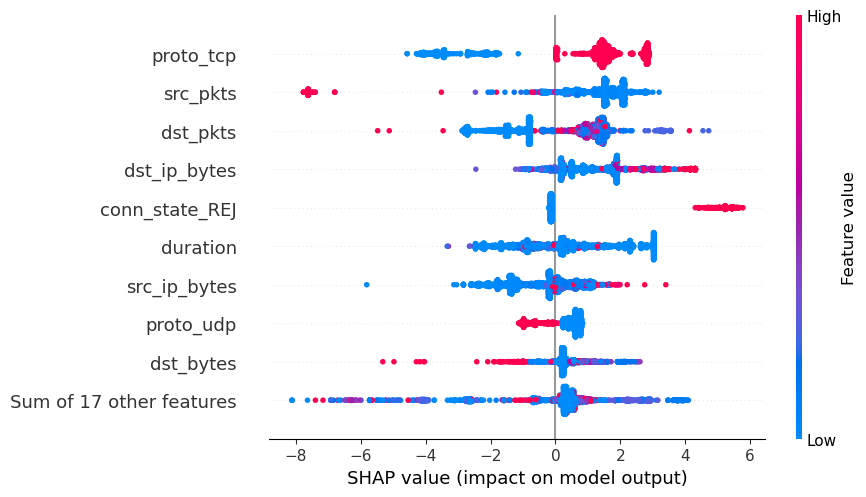

In [16]:
model_BC_xg, X_train_BC_xg, y_train_BC_xg, X_test_BC_xg, y_test_BC_xg = (
    runner_BC.get_model_data("XGBoost")
)

explainer_BC.plot_beeswarm(model_BC_xg, X_test_BC_xg)

LightGBM

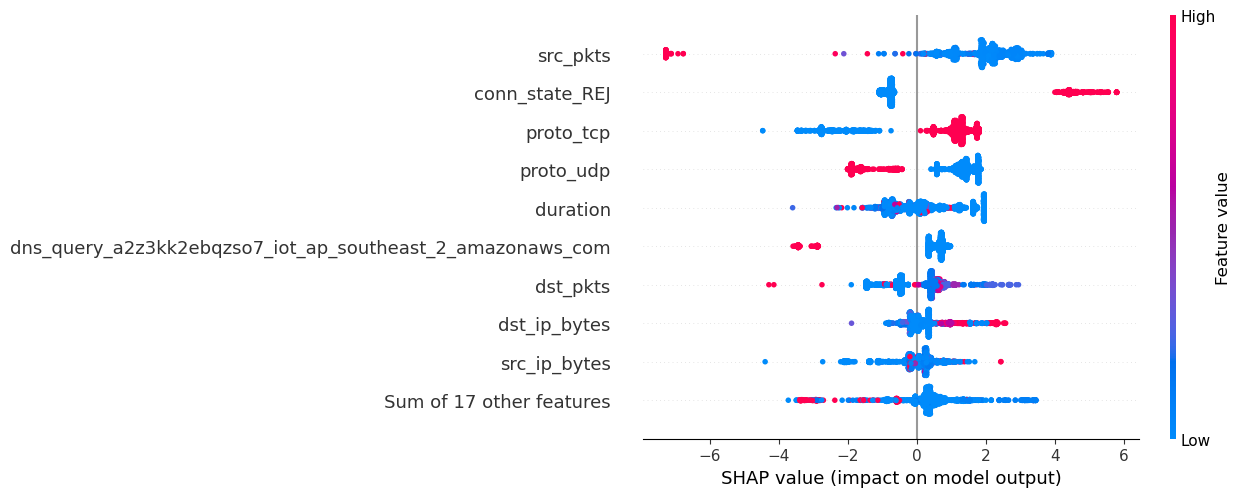

In [17]:
model_BC_lb, X_train_BC_lb, y_train_BC_lb, X_test_BC_lb, y_test_BC_lb = (
    runner_BC.get_model_data("LightGBM")
)

explainer_BC.plot_beeswarm(model_BC_lb, X_test_BC_lb)

#### 7.1.2. Multiclass

In [18]:
explainer_MC = SHAPTreeExplainer(task_type="multiclass", sample_size=2000, random_state=random_state)

RandomForest

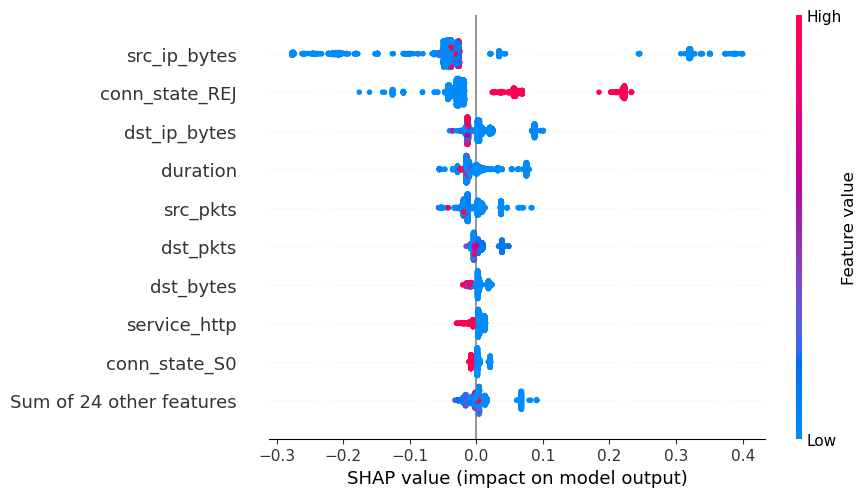

In [19]:
model_MC_rf, X_train_MC_rf, y_train_MC_rf, X_test_MC_rf, y_test_MC_rf = (
    runner_MC.get_model_data("RandomForest")
)

explainer_MC.plot_beeswarm(model_MC_rf, X_test_MC_rf, class_index=0)

ExtraTrees

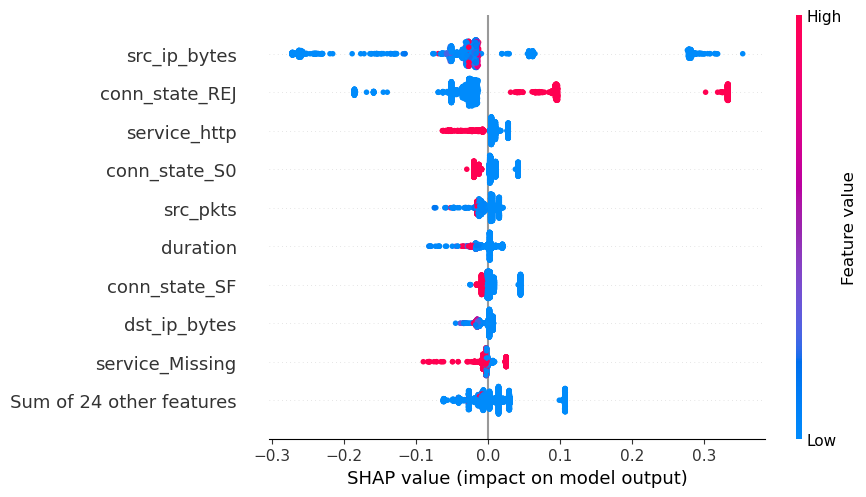

In [20]:
model_MC_et, X_train_MC_et, y_train_MC_et, X_test_MC_et, y_test_MC_et = (
    runner_MC.get_model_data("ExtraTrees")
)

explainer_MC.plot_beeswarm(model_MC_et, X_test_MC_et, class_index=0)

CatBoost

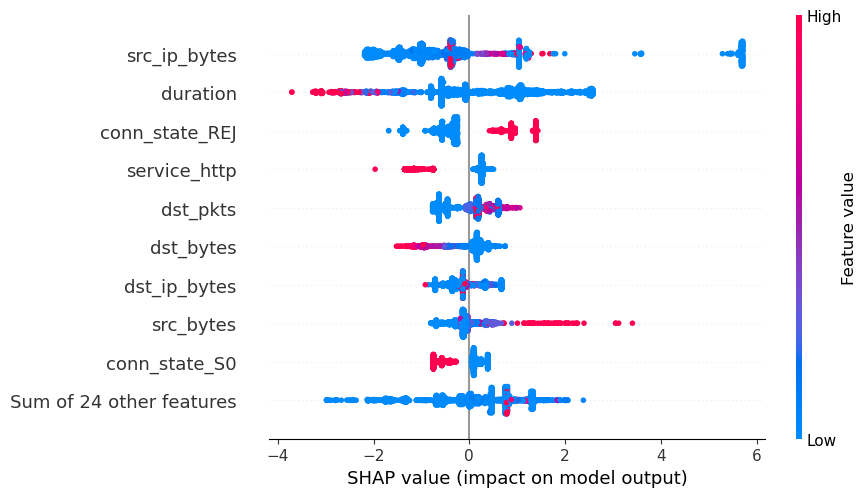

In [21]:
model_MC_cb, X_train_MC_cb, y_train_MC_cb, X_test_MC_cb, y_test_MC_cb = (
    runner_MC.get_model_data("CatBoost")
)

explainer_MC.plot_beeswarm(model_MC_cb, X_test_MC_cb, class_index=0)

XGBoost

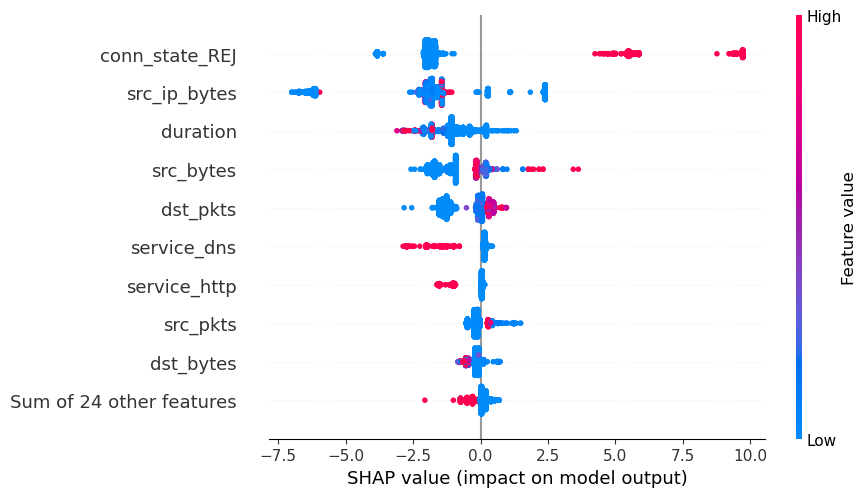

In [22]:
model_MC_xg, X_train_MC_xg, y_train_MC_xg, X_test_MC_xg, y_test_MC_xg = (
    runner_MC.get_model_data("XGBoost")
)

explainer_MC.plot_beeswarm(model_MC_xg, X_test_MC_xg, class_index=0)

LightGBM

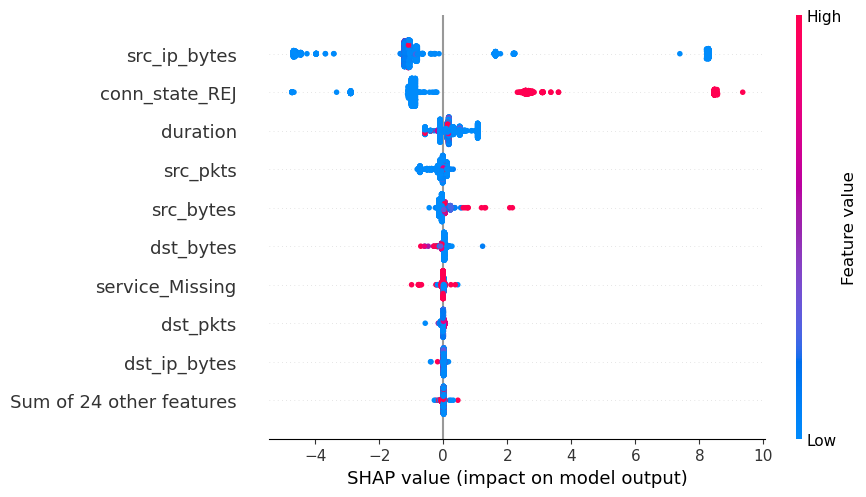

In [23]:
model_MC_lb, X_train_MC_lb, y_train_MC_lb, X_test_MC_lb, y_test_MC_lb = (
    runner_MC.get_model_data("LightGBM")
)

explainer_MC.plot_beeswarm(model_MC_lb, X_test_MC_lb, class_index=0)